# Age & Gender Prediction - Improved Model (Memory Efficient)

## Key Improvements Over Original
- **Transfer Learning** with MobileNetV2 (ImageNet pre-trained backbone)
- **Multi-Task Learning** - shared feature extractor with separate age/gender heads
- **Data Augmentation** - rotation, flips, brightness, zoom, shifts
- **GlobalAveragePooling2D** instead of Flatten (reduces overfitting)
- **Learning Rate Scheduling** with ReduceLROnPlateau
- **Early Stopping** to prevent overfitting
- **Class Weights** for imbalanced age groups
- **Consistent 224x224 input size** throughout
- **BatchNormalization + Dropout** in classification heads
- **Memory Efficient** - uses custom generator (loads images on-the-fly, NO OOM!)


In [1]:
# ===============================
# IMPORT LIBRARIES
# ===============================

import os
import glob
import gc
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, BatchNormalization,
    GlobalAveragePooling2D, Input
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical, Sequence
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    mean_absolute_error
)
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))


2026-06-12 11:04:05.732162: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781262245.908586     104 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781262245.959908     104 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781262246.373707     104 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781262246.373751     104 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781262246.373754     104 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
# ===============================
# PARAMETERS
# ===============================

IMG_SIZE = 224          # Match MobileNetV2 default input
BATCH_SIZE = 64         # Batch size for training
EPOCHS = 50             # Max epochs (early stopping will stop earlier)
LEARNING_RATE = 1e-4    # Lower LR for fine-tuning
TEST_SPLIT = 0.15      # 15% test
VAL_SPLIT = 0.15       # 15% validation (from remaining 85%)
RANDOM_STATE = 42
NUM_WORKERS = 2        # Parallel image loading workers


In [3]:
# ===============================
# LOAD UTKFACE DATASET
# ===============================

# Update this path to your UTKFace folder location
data_path = "/kaggle/input/datasets/nickstarzayswal/utkdata-face/UTKFace"

image_paths = glob.glob(os.path.join(data_path, "*.jpg"))

if len(image_paths) == 0:
    print("No images found. Check your folder path and ensure images are in .jpg format.")
else:
    print(f"Found {len(image_paths)} images. Dataset loaded successfully!")


Found 23708 images. Dataset loaded successfully!


In [4]:
# ===============================
# PARSE FILENAMES (NO IMAGE LOADING)
# ===============================
#
# This cell ONLY parses filenames to extract age and gender labels.
# We do NOT load images into memory here - that happens later
# in the custom generator, one batch at a time.
#
# This prevents the Out Of Memory (OOM) crash!

valid_paths = []
ages = []
genders = []
skipped = 0

for img_path in tqdm(image_paths, desc="Parsing filenames"):
    filename = os.path.basename(img_path)

    try:
        age = int(filename.split("_")[0])
        gender = int(filename.split("_")[1])
    except (ValueError, IndexError):
        skipped += 1
        continue

    if age < 0 or age > 116:
        skipped += 1
        continue

    valid_paths.append(img_path)
    ages.append(age)
    genders.append(gender)

print(f"\nValid images: {len(valid_paths)}")
print(f"Skipped: {skipped}")
print(f"Age range: {min(ages)} - {max(ages)}")
print(f"Gender: Male={genders.count(0)}, Female={genders.count(1)}")


Parsing filenames: 100%|██████████| 23708/23708 [00:00<00:00, 648983.56it/s]


Valid images: 23708
Skipped: 0
Age range: 1 - 116
Gender: Male=12391, Female=11317


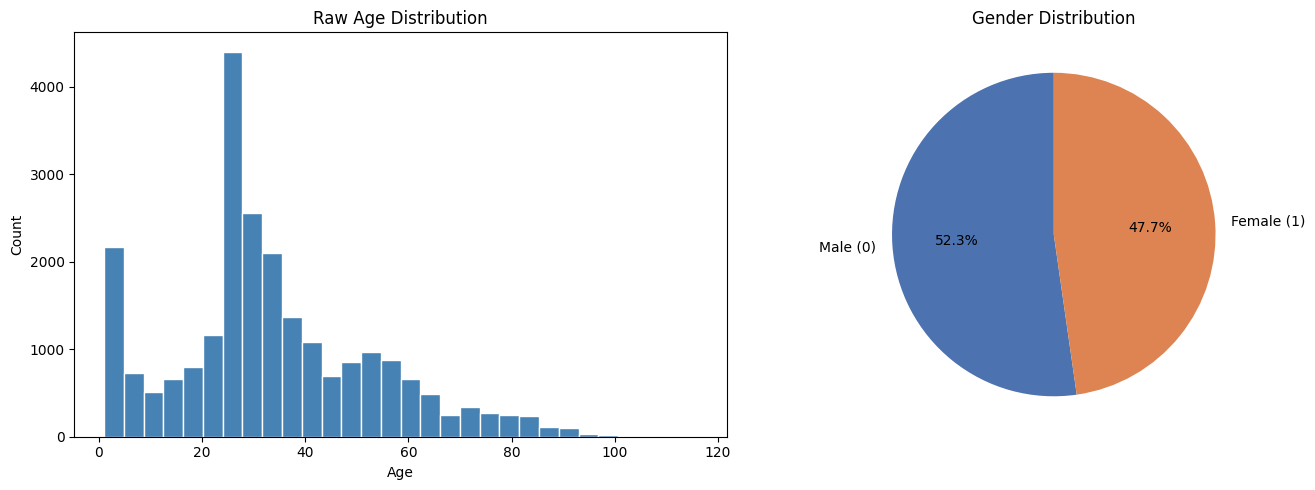

In [5]:
# ===============================
# EXPLORE AGE DISTRIBUTION
# ===============================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(ages, bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Raw Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

gender_counts = [genders.count(0), genders.count(1)]
axes[1].pie(gender_counts, labels=["Male (0)", "Female (1)"],
            autopct="%1.1f%%", colors=["#4c72b0", "#dd8452"], startangle=90)
axes[1].set_title("Gender Distribution")

plt.tight_layout()
plt.show()


In [6]:
# AGE BINNING (IMPROVED BALANCED BINS)
# ================================

age_bins = [0, 3, 8, 15, 22, 30, 40, 50, 60, np.inf]  # <-- changed 116 to np.inf
age_labels_list = [
    "0-3",
    "4-8",
    "9-15",
    "16-22",
    "23-30",
    "31-40",
    "41-50",
    "51-60",
    "61+",
]

NUM_AGE_CLASSES = len(age_labels_list)

# digitize + clip for safety against any out-of-range values
y_age_group = np.digitize(ages, age_bins) - 1
y_age_group = np.clip(y_age_group, 0, NUM_AGE_CLASSES - 1)   # <-- added safety clip

y_gender = np.array(genders, dtype=np.int32)
y_age_cat = to_categorical(y_age_group, num_classes=NUM_AGE_CLASSES)

print(f"Number of age classes: {NUM_AGE_CLASSES}")
print("Age group distribution:")
for i, label in enumerate(age_labels_list):
    count = np.sum(y_age_group == i)
    pct = count / len(y_age_group) * 100
    print(f"  Class {i} ({label:>6}): {count:>6} images ({pct:.1f}%)")

Number of age classes: 9
Age group distribution:
  Class 0 (   0-3):   1605 images (6.8%)
  Class 1 (   4-8):   1028 images (4.3%)
  Class 2 (  9-15):   1018 images (4.3%)
  Class 3 ( 16-22):   1572 images (6.6%)
  Class 4 ( 23-30):   6714 images (28.3%)
  Class 5 ( 31-40):   4537 images (19.1%)
  Class 6 ( 41-50):   2245 images (9.5%)
  Class 7 ( 51-60):   2299 images (9.7%)
  Class 8 (   61+):   2690 images (11.3%)


In [7]:
# ===============================
# CUSTOM DATA GENERATOR (Memory Efficient)
# ===============================
#
# This generator loads images from disk on-the-fly in batches.
# Only BATCH_SIZE images are in memory at any time.
# This prevents the Out Of Memory crash!

class FaceDataGenerator(Sequence):
    """
    Custom Keras data generator that loads images from disk in batches.
    Supports optional data augmentation.
    """

    def __init__(self, image_paths, y_gender, y_age_cat,
                 batch_size=64, img_size=224, augment=False, shuffle=True):
        self.image_paths = np.array(image_paths)
        self.y_gender = np.array(y_gender)
        self.y_age_cat = np.array(y_age_cat)
        self.batch_size = batch_size
        self.img_size = img_size
        self.augment = augment
        self.shuffle = shuffle
        self.indices = np.arange(len(self.image_paths))

        # Initialize augmentation
        if augment:
            self.datagen = ImageDataGenerator(
                rotation_range=15,
                width_shift_range=0.1,
                height_shift_range=0.1,
                horizontal_flip=True,
                brightness_range=[0.85, 1.15],
                zoom_range=0.1,
                shear_range=0.05,
                fill_mode="nearest",
            )
        else:
            self.datagen = None

        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[
            idx * self.batch_size : (idx + 1) * self.batch_size
        ]

        batch_images = []
        for i in batch_indices:
            img = cv2.imread(self.image_paths[i])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (self.img_size, self.img_size))
            img = img / 255.0
            batch_images.append(img)

        batch_images = np.array(batch_images, dtype=np.float32)

        # Apply augmentation
        if self.augment and self.datagen is not None:
            # Augment without changing labels (no label-dependent transforms)
            augmented = self.datagen.random_transform(batch_images[0])
            for i in range(len(batch_images)):
                batch_images[i] = self.datagen.random_transform(batch_images[i])

        batch_gender = self.y_gender[batch_indices]
        batch_age = self.y_age_cat[batch_indices]

        return batch_images, {
            "gender_output": batch_gender,
            "age_output": batch_age
        }

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


print("Custom FaceDataGenerator class defined!")
print("This loads images on-the-fly - NO OOM crashes!")


Custom FaceDataGenerator class defined!
This loads images on-the-fly - NO OOM crashes!


In [8]:
# ===============================
# TRAIN / VALIDATION / TEST SPLIT
# ===============================
#
# We split the PATHS (not images), so no images are loaded here.

# First split: test set
paths_train_val, paths_test, y_gender_train_val, y_gender_test, \
y_age_train_val, y_age_test = train_test_split(
    valid_paths, y_gender, y_age_cat,
    test_size=TEST_SPLIT, random_state=RANDOM_STATE, stratify=y_age_group
)

y_age_group_train_val = np.argmax(y_age_train_val, axis=1)

# Second split: validation set
paths_train, paths_val, y_gender_train, y_gender_val, \
y_age_train, y_age_val = train_test_split(
    paths_train_val, y_gender_train_val, y_age_train_val,
    test_size=VAL_SPLIT / (1 - TEST_SPLIT),
    random_state=RANDOM_STATE, stratify=y_age_group_train_val
)

print(f"Training set:   {len(paths_train)} images")
print(f"Validation set: {len(paths_val)} images")
print(f"Test set:       {len(paths_test)} images")

# Free unused memory
del paths_train_val, y_gender_train_val, y_age_train_val, y_age_group_train_val
gc.collect()


Training set:   16594 images
Validation set: 3557 images
Test set:       3557 images


0

In [9]:
# ===============================
# CREATE DATA GENERATORS
# ===============================

train_gen = FaceDataGenerator(
    paths_train, y_gender_train, y_age_train,
    batch_size=BATCH_SIZE, img_size=IMG_SIZE,
    augment=True, shuffle=True
)

val_gen = FaceDataGenerator(
    paths_val, y_gender_val, y_age_val,
    batch_size=BATCH_SIZE, img_size=IMG_SIZE,
    augment=False, shuffle=False
)

print(f"Training batches per epoch:   {len(train_gen)}")
print(f"Validation batches per epoch: {len(val_gen)}")

# Quick test: load one batch
test_imgs, test_labels = train_gen[0]
print(f"\nBatch image shape: {test_imgs.shape}")
print(f"Batch gender labels: {test_labels["gender_output"].shape}")
print(f"Batch age labels:   {test_labels["age_output"].shape}")


Training batches per epoch:   260
Validation batches per epoch: 56

Batch image shape: (64, 224, 224, 3)
Batch gender labels: (64,)
Batch age labels:   (64, 9)


In [10]:
# ===============================
# COMPUTE CLASS WEIGHTS FOR AGE GROUPS
# ===============================

y_age_group_train = np.argmax(y_age_train, axis=1)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_AGE_CLASSES),
    y=y_age_group_train
)
age_class_weights = dict(enumerate(class_weights_array))

print("Age class weights:")
for i, w in age_class_weights.items():
    print(f"  Class {i} ({age_labels_list[i]}): weight = {w:.3f}")


Age class weights:
  Class 0 (0-3): weight = 1.642
  Class 1 (4-8): weight = 2.561
  Class 2 (9-15): weight = 2.590
  Class 3 (16-22): weight = 1.676
  Class 4 (23-30): weight = 0.392
  Class 5 (31-40): weight = 0.581
  Class 6 (41-50): weight = 1.174
  Class 7 (51-60): weight = 1.146
  Class 8 (61+): weight = 0.979


In [11]:
# ===============================
# BUILD MULTI-TASK MODEL (IMPROVED)
# ===============================

def build_improved_model(num_age_classes):
    """
    Multi-task model with MobileNetV2 backbone.
    Outputs: gender (sigmoid) and age_group (softmax).
    """
    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="input")

    backbone = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_tensor=inputs,
        alpha=1.0
    )

    backbone.trainable = False

    x = backbone.output
    x = GlobalAveragePooling2D(name="gap")(x)
    x = BatchNormalization(name="bn_shared")(x)
    x = Dropout(0.3, name="dropout_shared")(x)

    # Gender Head
    g = Dense(128, activation="relu", name="gender_dense1")(x)
    g = BatchNormalization(name="gender_bn1")(g)
    g = Dropout(0.3, name="gender_dropout1")(g)
    g = Dense(64, activation="relu", name="gender_dense2")(g)
    g = BatchNormalization(name="gender_bn2")(g)
    g = Dropout(0.2, name="gender_dropout2")(g)
    gender_output = Dense(1, activation="sigmoid", name="gender_output")(g)

    # Age Head
    a = Dense(256, activation="relu", name="age_dense1")(x)
    a = BatchNormalization(name="age_bn1")(a)
    a = Dropout(0.3, name="age_dropout1")(a)
    a = Dense(128, activation="relu", name="age_dense2")(a)
    a = BatchNormalization(name="age_bn2")(a)
    a = Dropout(0.2, name="age_dropout2")(a)
    age_output = Dense(num_age_classes, activation="softmax", name="age_output")(a)

    model = Model(inputs=inputs, outputs=[gender_output, age_output],
                  name="age_gender_model")

    return model, backbone


model, backbone = build_improved_model(NUM_AGE_CLASSES)

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss={
        "gender_output": "binary_crossentropy",
        "age_output": "categorical_crossentropy"
    },
    loss_weights={
        "gender_output": 1.0,
        "age_output": 1.5
    },
    metrics={
        "gender_output": ["accuracy"],
        "age_output": ["accuracy"]
    }
)

print("\nModel Summary:")
model.summary()


/tmp/ipykernel_104/2061243736.py:12: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone = MobileNetV2(
I0000 00:00:1781262261.273852     104 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781262261.279590     104 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Model Summary:


Model: "age_gender_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,799,690 (10.68 MB)

 Trainable params: 537,994 (2.05 MB)

 Non-trainable params: 2,261,696 (8.63 MB)

In [12]:
# ===============================
# CALLBACKS
# ===============================

os.makedirs("/kaggle/working/models", exist_ok=True)

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        "/kaggle/working/models/best_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

print("Callbacks configured: EarlyStopping, ReduceLROnPlateau, ModelCheckpoint")


Callbacks configured: EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


## Phase 1: Train Classification Heads (Backbone Frozen)

We first train only the gender and age classification heads while keeping
the MobileNetV2 backbone frozen. This allows the new layers to learn
good initial weights before fine-tuning the backbone.

In [13]:
# ===============================
# PHASE 1: TRAIN HEADS (BACKBONE FROZEN)
# ===============================

print("=" * 50)
print("PHASE 1: Training classification heads (backbone frozen)")
print("=" * 50)

# history_phase1 = model.fit(
#     train_gen,
#     validation_data=val_gen,
#     epochs=EPOCHS,
#     callbacks=callbacks,
#     class_weight={
#         "gender_output": None,
#         "age_output": age_class_weights
#     }
# )
history_phase1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)


PHASE 1: Training classification heads (backbone frozen)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1781262274.606809     168 service.cc:152] XLA service 0x7fabec04f4c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781262274.606862     168 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781262274.606869     168 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781262276.233024     168 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-12 11:04:46.516997: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-12 11:04:46.656815: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1781262291.463795     168 device_co

 10/260 ━━━━━━━━━━━━━━━━━━━━ 4:05 982ms/step - age_output_accuracy: 0.1351 - age_output_loss: 2.9891 - gender_output_accuracy: 0.4784 - gender_output_loss: 0.8748 - loss: 5.3584

2026-06-12 11:05:10.673942: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-12 11:05:10.816371: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - age_output_accuracy: 0.1173 - age_output_loss: 2.8304 - gender_output_accuracy: 0.5052 - gender_output_loss: 0.8258 - loss: 5.0615

2026-06-12 11:10:27.456484: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-12 11:10:27.594520: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_loss improved from None to 6.09245, saving model to /kaggle/working/models/best_model.keras

Epoch 1: finished saving model to /kaggle/working/models/best_model.keras
260/260 ━━━━━━━━━━━━━━━━━━━━ 365s 1s/step - age_output_accuracy: 0.1202 - age_output_loss: 2.7307 - gender_output_accuracy: 0.5024 - gender_output_loss: 0.8094 - loss: 4.9017 - val_age_output_accuracy: 0.1482 - val_age_output_loss: 3.1353 - val_gender_output_accuracy: 0.4748 - val_gender_output_loss: 1.3884 - val_loss: 6.0925 - learning_rate: 1.0000e-04
Epoch 2/50
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 824ms/step - age_output_accuracy: 0.1339 - age_output_loss: 2.5670 - gender_output_accuracy: 0.4999 - gender_output_loss: 0.7822 - loss: 4.6327
Epoch 2: val_loss did not improve from 6.09245
260/260 ━━━━━━━━━━━━━━━━━━━━ 227s 872ms/step - age_output_accuracy: 0.1401 - age_output_loss: 2.5255 - gender_output_accuracy: 0.5076 - gender_output_loss: 0.7721 - loss: 4.5603 - val_age_output_accuracy: 0.1504 - val_age_output_

## Phase 2: Fine-Tune Backbone (Unfreezing Last 40 Layers)

Now we unfreeze the last 40 layers of MobileNetV2 and continue training
with a very small learning rate.

In [15]:
# ===============================
# PHASE 2: FINE-TUNE BACKBONE
# ===============================

# Unfreeze last 40 layers
for layer in backbone.layers[-40:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE / 10),
    loss={
        "gender_output": "binary_crossentropy",
        "age_output": "categorical_crossentropy"
    },
    loss_weights={
        "gender_output": 1.0,
        "age_output": 1.5
    },
    metrics={
        "gender_output": ["accuracy"],
        "age_output": ["accuracy"]
    }
)

ft_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-8,
        verbose=1
    ),
    ModelCheckpoint(
        "/kaggle/working/models/best_model_finetuned.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

print("=" * 50)
print("PHASE 2: Fine-tuning backbone (last 40 layers unfrozen)")
print("=" * 50)

# history_phase2 = model.fit(
#     train_gen,
#     validation_data=val_gen,
#     epochs=EPOCHS,
#     callbacks=ft_callbacks,
#     class_weight={
#         "gender_output": None,
#         "age_output": age_class_weights
#     }
# )
history_phase2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=ft_callbacks
)


PHASE 2: Fine-tuning backbone (last 40 layers unfrozen)
Epoch 1/50
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 935ms/step - age_output_accuracy: 0.1158 - age_output_loss: 2.7157 - gender_output_accuracy: 0.4989 - gender_output_loss: 0.8107 - loss: 4.8824
Epoch 1: val_loss improved from None to 7.32410, saving model to /kaggle/working/models/best_model_finetuned.keras

Epoch 1: finished saving model to /kaggle/working/models/best_model_finetuned.keras
260/260 ━━━━━━━━━━━━━━━━━━━━ 294s 1s/step - age_output_accuracy: 0.1225 - age_output_loss: 2.6749 - gender_output_accuracy: 0.5024 - gender_output_loss: 0.8058 - loss: 4.8167 - val_age_output_accuracy: 0.1763 - val_age_output_loss: 3.8876 - val_gender_output_accuracy: 0.4850 - val_gender_output_loss: 1.4920 - val_loss: 7.3241 - learning_rate: 1.0000e-05
Epoch 2/50
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 862ms/step - age_output_accuracy: 0.1236 - age_output_loss: 2.6667 - gender_output_accuracy: 0.5016 - gender_output_loss: 0.7990 - loss: 4.7990
Epoch 2: val_l

In [16]:
# ===============================
# SAVE FINAL MODELS
# ===============================

model.save("/kaggle/working/models/age_gender_model_final.keras")
print("Final model saved to /kaggle/working/models/age_gender_model_final.keras")


Final model saved to /kaggle/working/models/age_gender_model_final.keras


In [17]:
# ===============================
# EVALUATION ON TEST SET
# ===============================
#
# We create a test generator and evaluate.

test_gen = FaceDataGenerator(
    paths_test, y_gender_test, y_age_test,
    batch_size=BATCH_SIZE, img_size=IMG_SIZE,
    augment=False, shuffle=False
)

results = model.evaluate(
    test_gen,
    verbose=1
)

print("\n" + "=" * 50)
print("FINAL TEST RESULTS")
print("=" * 50)
print(f"Total Loss:                  {results[0]:.4f}")
print(f"Gender Loss (BCE):           {results[1]:.4f}")
print(f"Age Loss (CE):               {results[2]:.4f}")
print(f"Gender Accuracy:             {results[3]*100:.2f}%")
print(f"Age Group Accuracy:          {results[4]*100:.2f}%")


56/56 ━━━━━━━━━━━━━━━━━━━━ 33s 599ms/step - age_output_accuracy: 0.1217 - age_output_loss: 2.8076 - gender_output_accuracy: 0.4970 - gender_output_loss: 0.9807 - loss: 5.1964

FINAL TEST RESULTS
Total Loss:                  5.1964
Gender Loss (BCE):           0.9807
Age Loss (CE):               2.8076
Gender Accuracy:             12.17%
Age Group Accuracy:          49.70%


2026-06-12 15:14:45.216624: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-12 15:14:45.357271: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-12 15:14:45.493308: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-12 15:15:18.922330: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-12 15:15:19.075258: E external/local_xla/xla/stream_

Gender Classification Report:
              precision    recall  f1-score   support

        Male       0.51      0.84      0.63      1826
      Female       0.44      0.13      0.20      1731

    accuracy                           0.50      3557
   macro avg       0.48      0.49      0.42      3557
weighted avg       0.48      0.50      0.42      3557



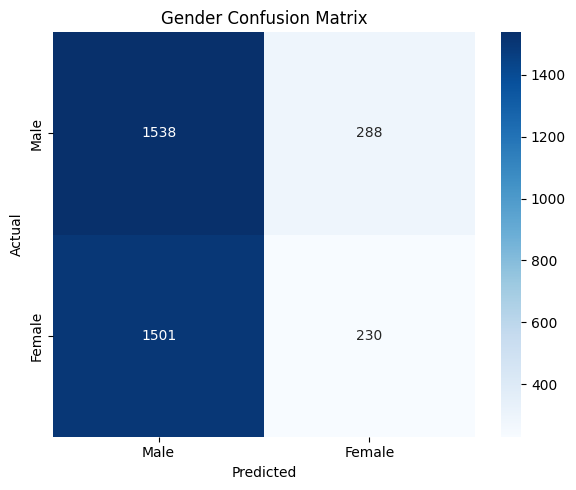

In [18]:
# ===============================
# GENDER DETAILED REPORT
# ===============================

# Collect all predictions
y_gender_pred_all = []
y_gender_true_all = []

for i in range(len(test_gen)):
    imgs, labels = test_gen[i]
    preds = model.predict(imgs, verbose=0)[0]
    y_gender_pred_all.extend((preds.flatten() > 0.5).astype(int))
    y_gender_true_all.extend(labels["gender_output"])

print("Gender Classification Report:")
print(classification_report(y_gender_true_all, y_gender_pred_all,
                            target_names=["Male", "Female"]))

cm = confusion_matrix(y_gender_true_all, y_gender_pred_all)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Male", "Female"], yticklabels=["Male", "Female"])
plt.title("Gender Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


Age Group Classification Report:
              precision    recall  f1-score   support

         0-3       0.08      0.00      0.01       241
         4-8       0.03      0.12      0.04       154
        9-15       0.05      0.18      0.08       153
       16-22       0.22      0.01      0.02       236
       23-30       0.22      0.22      0.22      1007
       31-40       0.17      0.17      0.17       681
       41-50       0.07      0.09      0.08       337
       51-60       0.07      0.02      0.04       345
         61+       0.03      0.00      0.00       403

    accuracy                           0.12      3557
   macro avg       0.11      0.09      0.07      3557
weighted avg       0.14      0.12      0.12      3557



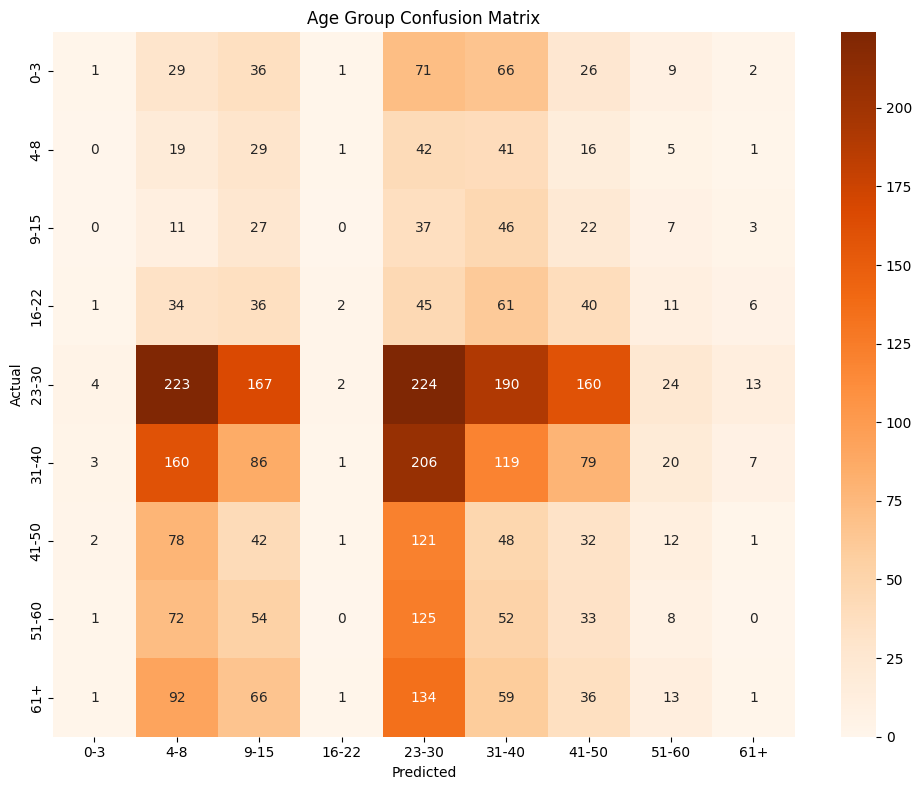

In [20]:
# ===============================
# AGE DETAILED REPORT
# ===============================

y_age_pred_all = []
y_age_true_all = []

for i in range(len(test_gen)):
    imgs, labels = test_gen[i]
    preds = model.predict(imgs, verbose=0)[1]
    y_age_pred_all.extend(np.argmax(preds, axis=1))
    y_age_true_all.extend(np.argmax(labels["age_output"], axis=1))

print("Age Group Classification Report:")
print(classification_report(y_age_true_all, y_age_pred_all,
                            target_names=age_labels_list))

cm_age = confusion_matrix(y_age_true_all, y_age_pred_all)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_age, annot=True, fmt="d", cmap="Oranges",
            xticklabels=age_labels_list, yticklabels=age_labels_list)
plt.title("Age Group Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


2026-06-12 15:16:17.293293: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-12 15:16:17.436295: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


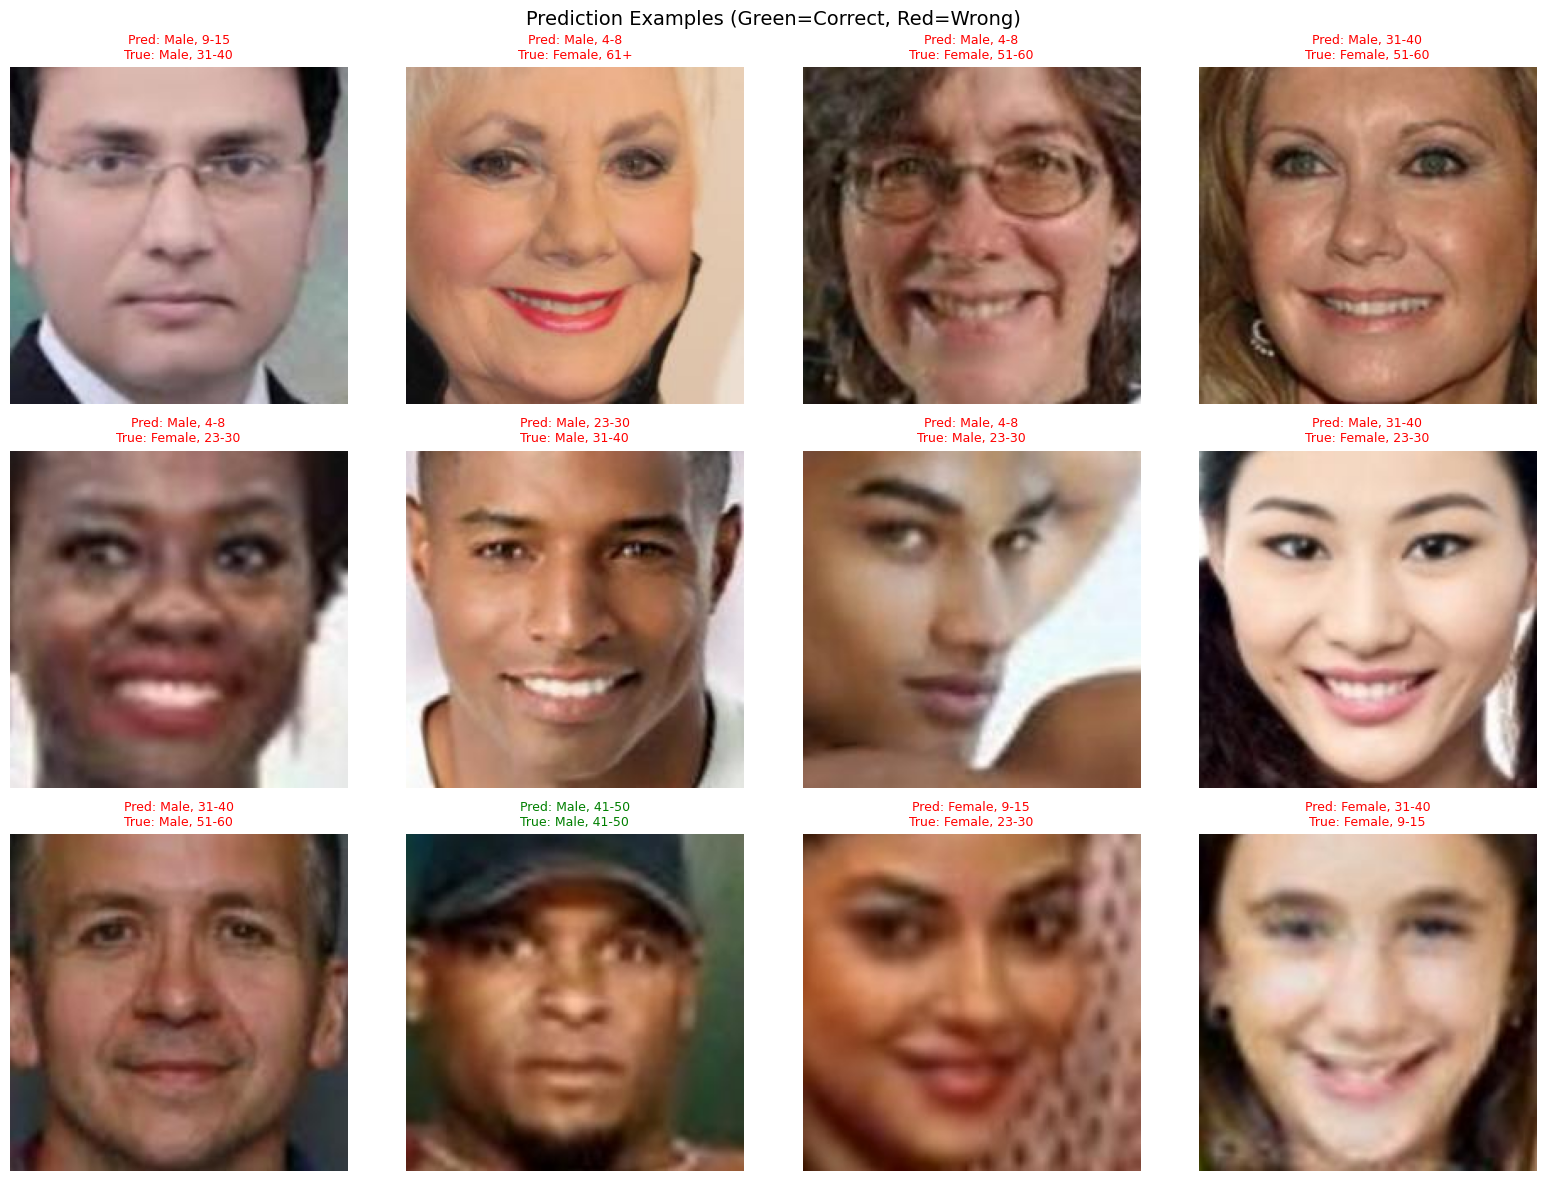

In [21]:
# ===============================
# PREDICTION EXAMPLES
# ===============================

num_examples = 12
sample_indices = np.random.choice(len(paths_test), num_examples, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, idx in enumerate(sample_indices):
    img = cv2.imread(paths_test[idx])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_disp = img.copy()

    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0
    img_input = np.expand_dims(img_resized, axis=0)

    gender_pred, age_pred = model.predict(img_input, verbose=0)
    pred_gender = "Male" if gender_pred[0][0] < 0.5 else "Female"
    pred_age = age_labels_list[np.argmax(age_pred[0])]

    true_gender = "Male" if y_gender_test[idx] == 0 else "Female"
    true_age = age_labels_list[np.argmax(y_age_test[idx])]

    g_ok = (pred_gender == true_gender)
    a_ok = (pred_age == true_age)
    color = "green" if (g_ok and a_ok) else "red"

    axes[i].imshow(img_disp)
    axes[i].axis("off")
    axes[i].set_title(
        f"Pred: {pred_gender}, {pred_age}\nTrue: {true_gender}, {true_age}",
        fontsize=9, color=color
    )

plt.suptitle("Prediction Examples (Green=Correct, Red=Wrong)", fontsize=14)
plt.tight_layout()
plt.show()


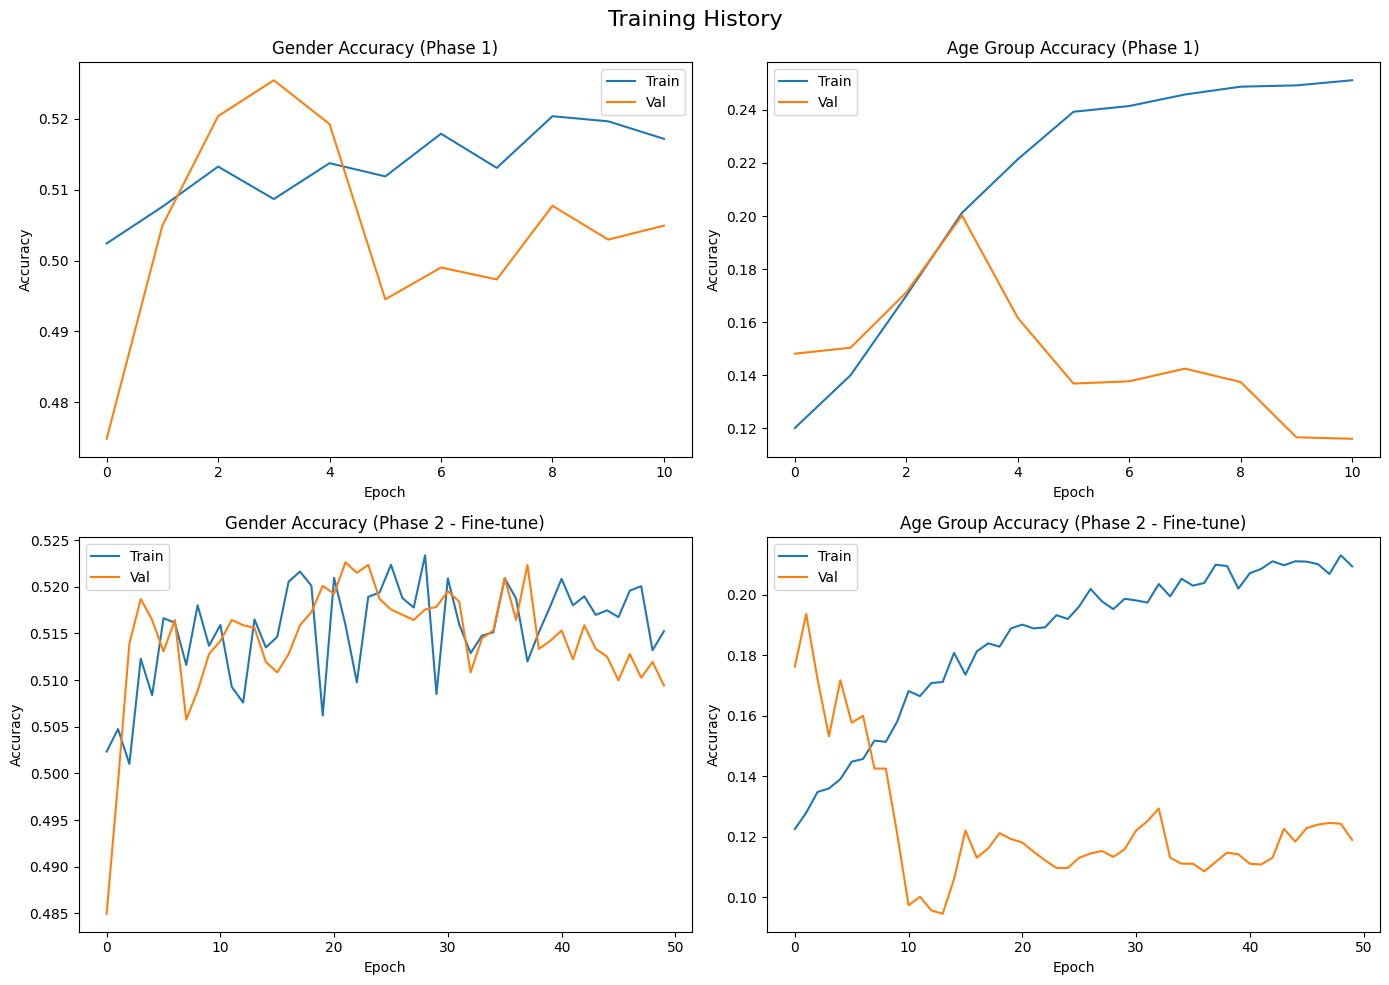

In [22]:
# ===============================
# TRAINING HISTORY PLOTS
# ===============================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(history_phase1.history["gender_output_accuracy"], label="Train")
axes[0, 0].plot(history_phase1.history["val_gender_output_accuracy"], label="Val")
axes[0, 0].set_title("Gender Accuracy (Phase 1)")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].legend(loc="best")

axes[0, 1].plot(history_phase1.history["age_output_accuracy"], label="Train")
axes[0, 1].plot(history_phase1.history["val_age_output_accuracy"], label="Val")
axes[0, 1].set_title("Age Group Accuracy (Phase 1)")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].legend(loc="best")

axes[1, 0].plot(history_phase2.history["gender_output_accuracy"], label="Train")
axes[1, 0].plot(history_phase2.history["val_gender_output_accuracy"], label="Val")
axes[1, 0].set_title("Gender Accuracy (Phase 2 - Fine-tune)")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Accuracy")
axes[1, 0].legend(loc="best")

axes[1, 1].plot(history_phase2.history["age_output_accuracy"], label="Train")
axes[1, 1].plot(history_phase2.history["val_age_output_accuracy"], label="Val")
axes[1, 1].set_title("Age Group Accuracy (Phase 2 - Fine-tune)")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Accuracy")
axes[1, 1].legend(loc="best")

plt.suptitle("Training History", fontsize=16)
plt.tight_layout()
plt.show()


In [24]:
# ===============================
# INFERENCE FUNCTION (For New Images)
# ===============================

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

def predict_age_gender(image_path_or_array):
    """
    Predict age group and gender from an image.
    Automatically detects and crops the face.
    """
    if isinstance(image_path_or_array, str):
        img = cv2.imread(image_path_or_array)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    else:
        img = image_path_or_array.copy()

    # Detect face
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    if len(faces) > 0:
        x, y, w, h = faces[0]
        img = img[y:y+h, x:x+w]

    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0
    img_input = np.expand_dims(img_resized, axis=0)

    gender_pred, age_pred = model.predict(img_input, verbose=0)

    gender = "Male" if gender_pred[0][0] < 0.5 else "Female"
    gender_conf = gender_pred[0][0] if gender == "Male" else 1 - gender_pred[0][0]
    age_idx = np.argmax(age_pred[0])
    age_group = age_labels_list[age_idx]
    age_conf = age_pred[0][age_idx]

    return {
        "gender": gender,
        "gender_confidence": float(gender_conf),
        "age_group": age_group,
        "age_confidence": float(age_conf)
    }

print("Inference function ready!")


Inference function ready!


## Webcam Real-Time Prediction (Optional)

Uncomment below to run on your local machine (not Kaggle).

In [ ]:
# # ===============================
# # WEBCAM REAL-TIME PREDICTION
# # ===============================

# cap = cv2.VideoCapture(0)

# while True:
#     ret, frame = cap.read()
#     if not ret:
#         break

#     result = predict_age_gender(frame)

#     gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
#     faces = face_cascade.detectMultiScale(gray, 1.3, 5)

#     for (x, y, w, h) in faces:
#         label = f"{result['gender']} ({result['gender_confidence']:.0%}), " \
#                 f"Age: {result['age_group']} ({result['age_confidence']:.0%})"
#         cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
#         cv2.putText(frame, label, (x, y-10),
#                     cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

#     cv2.imshow("Age & Gender Detection", frame)
#     if cv2.waitKey(1) & 0xFF == ord("q"):
#         break

# cap.release()
# cv2.destroyAllWindows()
